# Proiect: Detectia cancerului mamar

##Cirstea Mihnea-Codrut, Ozdemir Ali-Mert


Acest notebook implementeaza trei metode de clasificare pentru diagnosticul cancerului mamar:
- **Logistic Regression**

  Este un clasificator liniar utilizat ca punct de referinta (baseline). Estimeaza probabilitatea ca o tumora sa fie maligna aplicand functia sigmoid asupra unei combinatii liniare a trasaturilor

- **Gaussian Naive Bayes**

  Este un model probabilistic bazat pe Teorema lui Bayes, care presupune ca trasaturile sunt independente conditionat de clasa. In varianta GaussianNB, fiecare trasatura continua este modelata cu o distributie normala diferita pentru clasa benigna si pentru clasa maligna. Metoda este robusta la zgomot si ofera o estimare directa a probabilitatilor de apartenenta la fiecare clasa.

- **SVM Neliniar (Support Vector Machine cu Kernel RBF)**

  Functia de baza radiala (RBF) reprezinta tehnica standard prin care algoritmul SVM este adaptat pentru a solutiona probleme de clasificare cu separabilitate neliniara.

Set de date: **Breast Cancer Wisconsin (Diagnostic)** (UCI / disponibil prin `sklearn.datasets`).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.svm import SVC


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Descrierea aplicatiei si setului de date

**Aplicatia:**  
Aceasta aplicatie medicala are ca scop asistarea medicilor in diagnosticarea cancerului mamar.  
Sistemul clasifica automat biopsiile in doua categorii: **Maligne (canceroase)** sau **Benigne (sanatoase)**.

**Setul de date:** *Breast Cancer Wisconsin (Diagnostic)* (UCI Machine Learning Repository).  
- Datele sunt extrase din imagini digitalizate.  
- Contine **569** de instante (pacienti).  
- Are **30** de trasaturi numerice (input): raza, textura, perimetrul, aria, netezimea etc.  
- Output (Target): `0 = Malign`, `1 = Benign`.  


In [ ]:
# Incarcare date
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names


df_view = pd.DataFrame(X, columns=feature_names)
df_view['Diagnosis'] = y

print(f"Dimensiunea setului de date: {df_view.shape}")
print("Distributia claselor:")
print(df_view['Diagnosis'].value_counts().rename({0:'Malign', 1:'Benign'}))


Dimensiunea setului de date: (569, 31)
Distributia claselor:
Diagnosis
Benign    357
Malign    212
Name: count, dtype: int64


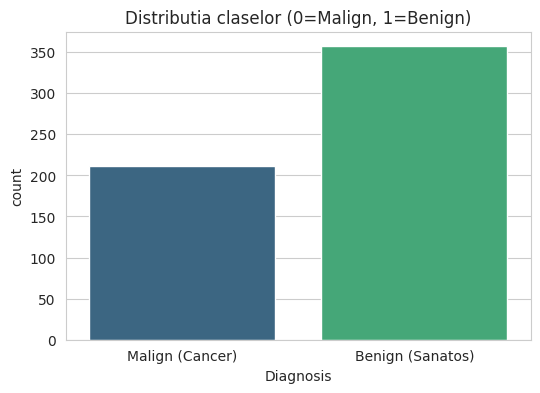

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Diagnosis', data=df_view, hue='Diagnosis', palette='viridis', legend=False)
plt.title('Distributia claselor (0=Malign, 1=Benign)')
plt.xticks([0, 1], ['Malign (Cancer)', 'Benign (Sanatos)'])
plt.show()



## 2. Preprocesarea datelor

Pasul de preprocesare este **critic** pentru acest set de date.

1. **Impartire Train/Test**: separam datele in **80% antrenare** si **20% testare** pentru o evaluare corecta.  
2. **Standardizare (StandardScaler)**:
   - Trasaturile au scari foarte diferite (ex: *Area* ~1000, *Smoothness* ~0.08).
   - Fara standardizare, Logistic Regression si in special SVM-ul pot fi dominate de trasaturile cu valori mari, ceea ce distorsioneaza calculul distantelor, iar in cazul Gaussian Naive Bayes pot cauza instabilitate numerica in estimarea probabilitatilor.
   - Transformarea:  ( z = (x - μ) / σ ).  
      * z: Noua valoare transformata (scorul Z).
      * x: Valoarea originala a trasaturii.
      * μ: Media aritmetica a acelei trasaturi pe tot setul de date.
      * σ: Deviatia standard (gradul de imprastiere a datelor).

*De ce este necesara?*

* Uniformizare: Aduce toate trasaturile la aceeasi scara (medie 0, deviatie 1).

* Eliminare Bias: Impiedica algoritmul sa considere eronat ca valorile numerice mari sunt mai importante.

* Performanta: Accelereaza convergenta pentru Logistic Regression si este obligatorie pentru kernel-ul RBF din SVM (care calculeaza distantele geometrice dintre puncte). Desi Gaussian Naive Bayes este robust la scalare, standardizarea asigura stabilitatea numerica a calculelor probabilitatilor.

3. **PCA**: reducerea dimensionalitatii pentru vizualizare 2D – Pentru transformarea intr-un set mai mic de variabile noi (componente principale), util pentru a vizualiza separabilitatea claselor inainte de aplicarea modelelor.


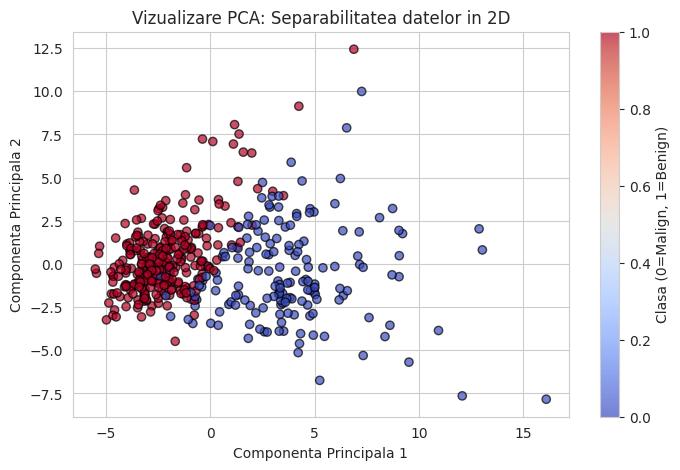

In [ ]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardizare
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# PCA pentru vizualizare
pca = PCA(n_components=2)
X_pca_train = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(
    X_pca_train[:, 0], X_pca_train[:, 1],
    c=y_train, cmap='coolwarm', alpha=0.7, edgecolors='k'
)
plt.title('Vizualizare PCA: Separabilitatea datelor in 2D')
plt.xlabel('Componenta Principala 1')
plt.ylabel('Componenta Principala 2')
plt.colorbar(label='Clasa (0=Malign, 1=Benign)')
plt.show()


## 3. Metode implementate (Logistic Regression, CNN, SVM Neliniar)

### Metoda 1: Logistic Regression

- Modelul de baza (Baseline): Este standardul in industria medicala pentru clasificarea binara, oferind un punct de referinta pentru performanta modelelor mai complexe.

- Mecanism (Functia Sigmoid): Transforma o combinatie liniara a trasaturilor (suma ponderata) intr-o valoare de probabilitate intre 0 si 1.

- Decizia: Se aplica un prag (de obicei 0.5). Daca probabilitatea calculata > 0.5, tumora este clasificata ca Maligna, altfel Benigna.

- Interpretare: Ne spune nu doar clasa, ci si cat de sigur este modelul (ex: 95% sanse de malignitate).

### Metoda 2: Gaussian Naive Bayes
Abordare Probabilistica: Spre deosebire de celelalte metode care cauta frontiere geometrice, acest algoritm se bazeaza pe Teorema lui Bayes. Calculeaza probabilitatea ca un pacient sa aiba un diagnostic (Malign/Benign) avand in vedere valorile masurate ale trasaturilor.

Mecanism (Distributia Gaussiana): Deoarece lucram cu date numerice continue (raza, perimetru, etc.), algoritmul presupune ca valorile asociate fiecarei clase urmeaza o distributie normala (Clopotul lui Gauss). Modelul invata media si deviatia standard pentru fiecare trasatura in parte.Simplifica problema considerand ca trasaturile sunt independente intre ele,de exemplu presupune ca raza nu influenteaza aria.

Este stabil pe seturi de date mici (cum este acesta), nefiind predispus la overfitting. Overfitting-ul inseamna ca modelul invata prea bine exemplele din setul de antrenare si ajunge sa memoreze zgomotul, nu doar regulile generale. Pe train are rezultate foarte bune, dar pe date noi performanta scade, deci modelul nu generalizeaza.

### Metoda 3: SVM Neliniar (Support Vector Machine cu Kernel RBF)

Fundament teoretic: SVM este un algoritm de invatare supervizata care cauta hiperplanul de separare cu marja maxima intre clase. Marja este distanta dintre hiperplan si cele mai apropiate puncte din fiecare clasa, numite vectori suport.

Kernel RBF: Cand datele nu sunt liniar separabile in spatiul initial al trasaturilor, folosim un kernel. Kernelul RBF (radial) mapeaza implicit vectorii de intrare intr-un spatiu de caracteristici de dimensiune mare, unde clasele devin mai usor separabile liniar. In spatiul original, acest lucru se traduce printr-o frontiera de decizie curba.

Parametrii de regularizare (C si gamma): Parametrul controleaza cat de mult penalizam erorile de clasificare pe setul de antrenare (compromis intre marja mare si putine greseli). Parametrul γ stabileste cat de locala este influenta fiecarui punct de antrenare: valori mari de γ duc la frontiere foarte curbate (risc de overfitting), iar valori mici la frontiere mai netede.

In [ ]:
#LOGISTIC REGRESSION
print("Antrenare Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
print("Antrenare completa.")


Antrenare Logistic Regression...
Antrenare completa.


In [ ]:
# Gaussian Naive Bayes
print("Antrenare Gaussian Naive Bayes...")
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
print("Antrenare completa.")

# Predictii pe setul de test
y_pred_nb = nb_model.predict(X_test_scaled)

acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb  = f1_score(y_test, y_pred_nb)

print(f"Acuratete Gaussian NB: {acc_nb:.4f}")
print(f"F1-Score Gaussian NB: {f1_nb:.4f}")


Antrenare Gaussian Naive Bayes...
Antrenare completa.
Acuratete Gaussian NB: 0.9649
F1-Score Gaussian NB: 0.9722


In [ ]:
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)

# Antrenare
svm_rbf.fit(X_train_scaled, y_train)

# Predictie
y_pred_svm = svm_rbf.predict(X_test_scaled)

# Calcul acuratete
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"Acuratete SVM (RBF): {acc_svm:.2%}")

Acuratete SVM (RBF): 98.25%


## 4. Analiza si compararea rezultatelor

Comparam **Acuratetea** si **F1-Score** pentru:
- Logistic Regression
- Gaussian Naive Bayes
- SVM Neliniar (RBF)




In [ ]:
# Calcul metrici Logistic Regression
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr)

# Calcul metrici Gaussian Naive Bayes
acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb  = f1_score(y_test, y_pred_nb)

# Calcul metrici SVM (kernel RBF)
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm)

# Tabel comparativ
results_df = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Gaussian Naive Bayes', 'SVM (Kernel RBF)'],
    'Acuratete': [acc_lr, acc_nb,acc_svm],
    'F1-Score': [f1_lr,f1_nb,f1_svm]
})

print("Tabel de Performanta:")
display(results_df)


Tabel de Performanta:


,Model,Acuratete,F1-Score
0,Logistic Regression,0.973684,0.979021
1,Gaussian Naive Bayes,0.964912,0.972222
2,SVM (Kernel RBF),0.982456,0.986111


Locul 1 – SVM Neliniar (RBF)
A obtinut cea mai buna performanta (Acc ~98.25%, F1 ~0.986).Rezultatul confirma ca exista o frontiera de decizie neliniara intre clase, iar kernel-ul RBF reuseste sa modeleze cel mai bine aceste relatii complexe, fiind cea mai robusta metoda pe acest set.

Locul 2 – Logistic Regression
Cu o precizie de (Acc ≈ 97.37%, F1 ≈ 0.979), extrem de apropiata de SVM, rezultatele subliniaza separabilitatea liniara a trasaturilor. Astfel, modelul reprezinta un compromis intre performanta si cost computational.

Locul 3 – Gaussian Naive Bayes
Are o performanta usor mai slaba (Acc ≈ 96.49%, F1 ≈ 0.972), dar tot buna in termeni absoluti. Modelul probabilistic este foarte rapid si stabil pe seturi mici, insa ipoteza de independenta intre trasaturi il limiteaza: nu reuseste sa capteze la fel de bine interactiunile complexe dintre caracteristici precum SVM si Logistic Regression.

# Concluzii

Comparatia metodelor a aratat ca SVM neliniar cu kernel RBF obtine
cea mai buna performanta globala (Acc ≈ 98.25%, F1 ≈ 0.986),
sugerand existenta unei frontiere de decizie neliniare intre clase si
capacitatea superioara a acestui model de a capta interactiuni
complexe intre trasaturi. Logistic Regression atinge performante
foarte apropiate (Acc ≈ 97.37%, F1 ≈ 0.979), ceea ce indica faptul ca
datele sunt aproape liniar separabile si ca trasaturile extrase sunt
extrem de relevante din punct de vedere clinic. Gaussian Naive Bayes
se situeaza usor sub aceste doua metode (Acc ≈ 96.49%, F1 ≈ 0.972),
dar ramane competitiv, mai ales prin simplitatea si viteza de
antrenare.

Analiza matricelor de confuzie a aratat ca, din perspectiva aplicatiilor
medicale, SVM neliniar este metoda cea mai sigura: nu produce
alarme false pentru pacienti sanatosi (0 False Positives) si
minimizeaza numarul de cazuri maligne ratate (2 False Negatives).
Logistic Regression are un profil de eroare foarte asemanator, cu
acelasi numar de cazuri maligne omise, dar cu un False Positive
suplimentar. Gaussian Naive Bayes inregistreaza cel mai mare numar
de False Negatives, ceea ce il face mai putin potrivit atunci cand
costul ratarii unui cancer este considerat critic.

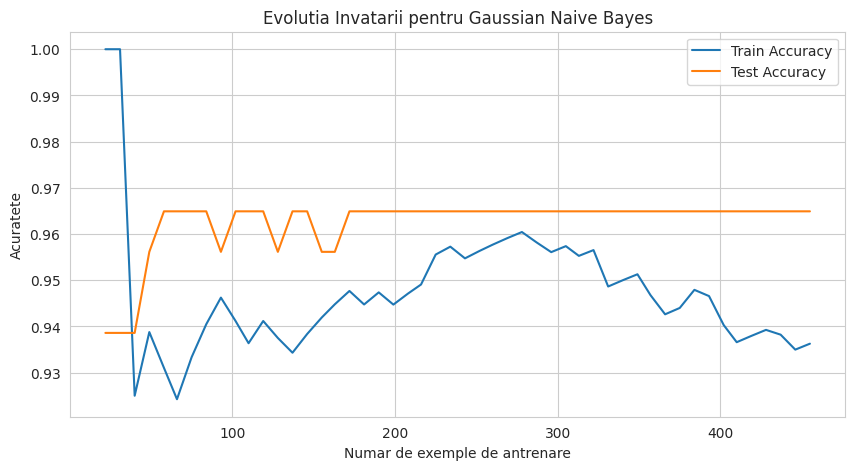

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.naive_bayes import GaussianNB

train_acc = []
test_acc = []


data_percentages = np.linspace(0.05, 1.0, 50)
x_ticks = []

for p in data_percentages:

    size = int(p * X_train_scaled.shape[0])
    x_ticks.append(size)


    X_subset = X_train_scaled[:size]
    y_subset = y_train[:size]

    if len(np.unique(y_subset)) < 2:
        train_acc.append(0)
        test_acc.append(0)
        continue

    gnb_history = GaussianNB()
    gnb_history.fit(X_subset, y_subset)


    train_acc.append(gnb_history.score(X_subset, y_subset))
    test_acc.append(gnb_history.score(X_test_scaled, y_test))

# Plotare
plt.figure(figsize=(10, 5))
plt.plot(x_ticks, train_acc, label='Train Accuracy')
plt.plot(x_ticks, test_acc, label='Test Accuracy')
plt.title('Evolutia Invatarii pentru Gaussian Naive Bayes')
plt.xlabel('Numar de exemple de antrenare')
plt.ylabel('Acuratete')
plt.legend()
plt.show()

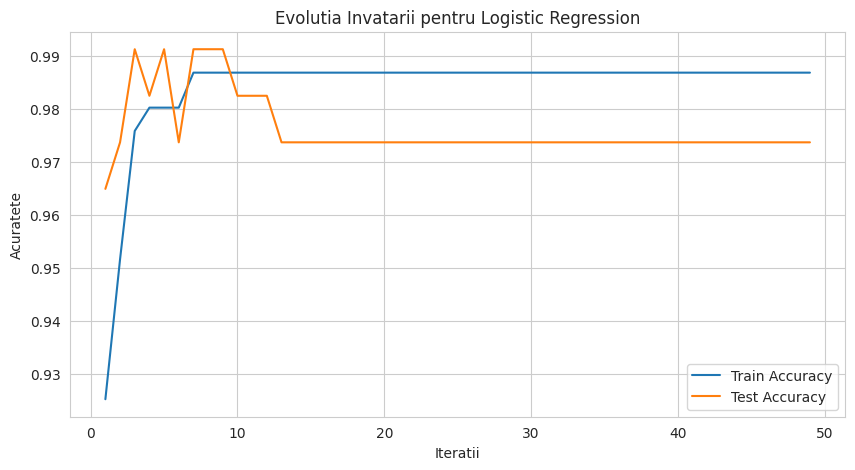

In [ ]:
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore", category=ConvergenceWarning)

train_acc = []
test_acc = []
iters = range(1, 50)

for i in iters:
    lr_history = LogisticRegression(max_iter=i, random_state=42)
    lr_history.fit(X_train_scaled, y_train)

    train_acc.append(lr_history.score(X_train_scaled, y_train))
    test_acc.append(lr_history.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 5))
plt.plot(iters, train_acc, label='Train Accuracy')
plt.plot(iters, test_acc,  label='Test Accuracy')
plt.title('Evolutia Invatarii pentru Logistic Regression')
plt.xlabel('Iteratii')
plt.ylabel('Acuratete')
plt.legend()
plt.show()


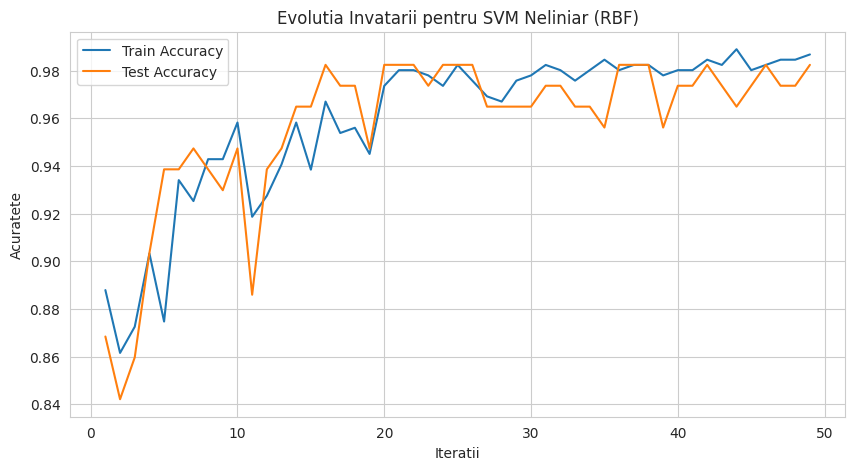

In [ ]:
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=ConvergenceWarning)

train_acc_svm = []
test_acc_svm = []

iters = range(1, 50)

for i in iters:
    svm_history = SVC(kernel='rbf', C=1.0, gamma='scale', max_iter=i, random_state=42)
    svm_history.fit(X_train_scaled, y_train)

    train_acc_svm.append(svm_history.score(X_train_scaled, y_train))
    test_acc_svm.append(svm_history.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 5))
plt.plot(iters, train_acc_svm, label='Train Accuracy')
plt.plot(iters, test_acc_svm, label='Test Accuracy')
plt.title('Evolutia Invatarii pentru SVM Neliniar (RBF)')
plt.xlabel('Iteratii')
plt.ylabel('Acuratete')
plt.legend()
plt.show()

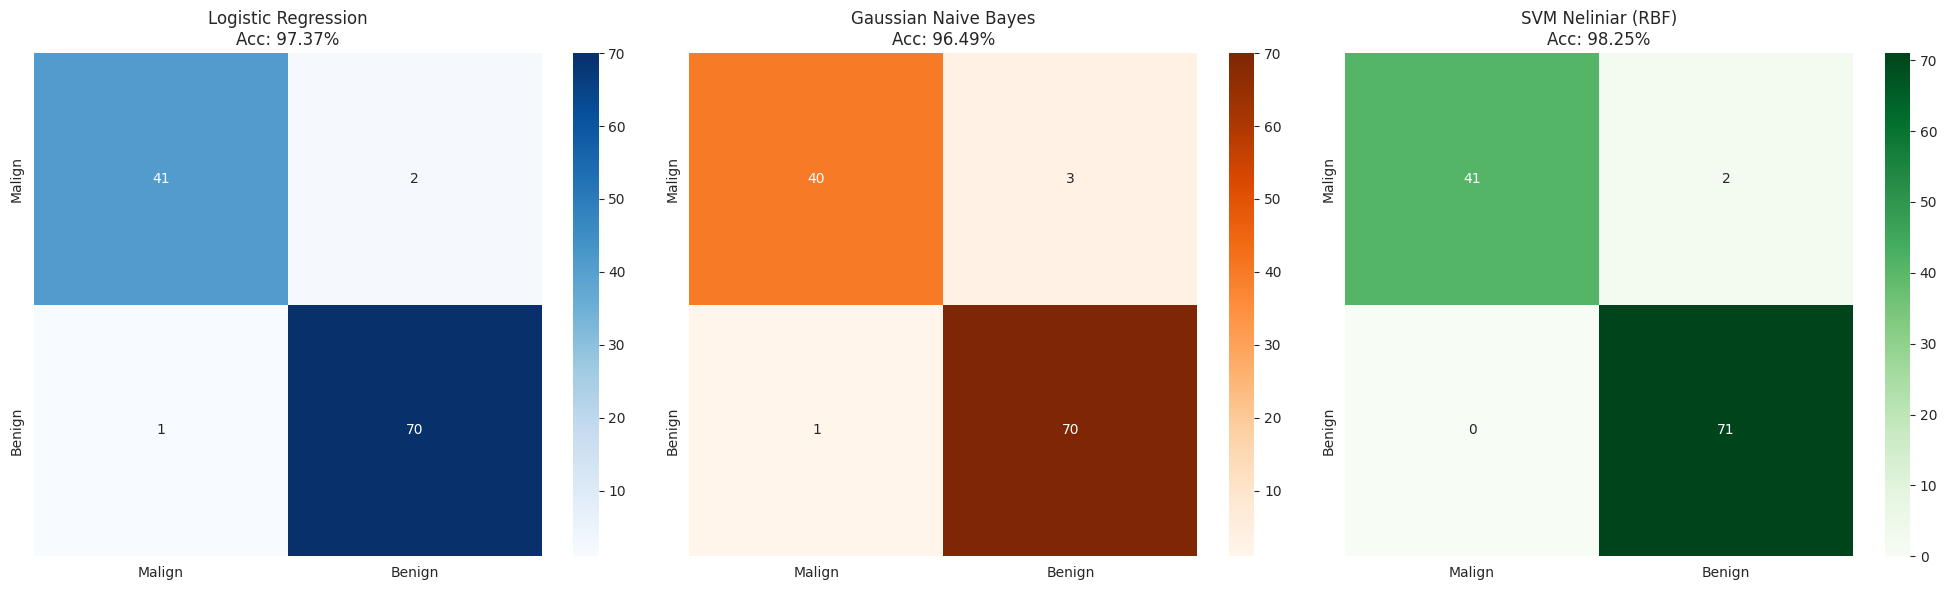

In [ ]:
#Matrice de Confuzie Comparativa
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# LR
sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Malign', 'Benign'],
    yticklabels=['Malign', 'Benign']
)
axes[0].set_title(f"Logistic Regression\nAcc: {acc_lr:.2%}")

# Gaussian Naive Bayes
sns.heatmap(
    confusion_matrix(y_test, y_pred_nb),
    annot=True, fmt='d', cmap='Oranges', ax=axes[1],
    xticklabels=['Malign', 'Benign'],
    yticklabels=['Malign', 'Benign']
)
axes[1].set_title(f"Gaussian Naive Bayes\nAcc: {acc_nb:.2%}")

# SVM Neliniar
sns.heatmap(
    confusion_matrix(y_test, y_pred_svm),
    annot=True, fmt='d', cmap='Greens', ax=axes[2],
    xticklabels=['Malign', 'Benign'],
    yticklabels=['Malign', 'Benign']
)
axes[2].set_title(f"SVM Neliniar (RBF)\nAcc: {acc_svm:.2%}")

plt.tight_layout()
plt.show()


* SVM Neliniar(RBF): Este cea mai sigura metoda. A inregistrat 0 False Positives (niciun pacient sanatos diagnosticat gresit) si minimul de 2 False Negatives (cazuri maligne ratate), oferind cel mai bun echilibru Precision-Recall.

* Logistic Regression: Performanta similara la detectarea cancerului (2 False Negatives), dar a avut 1 False Positive, ceea ce reduce usor scorul de precizie fata de SVM.

* Gaussian Naive Bayes: Are performanta usor mai slaba decat Logistic Regression, cu 3 False Negatives (mai multe cazuri maligne ratate) si 1 False Positive.